## 3. Univariate and Bivariate Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('fraud_preprocessed.csv')
print('Shape:', df.shape)

Shape: (50000, 23)


Fraud_Label
0    33933
1    16067
Name: count, dtype: int64


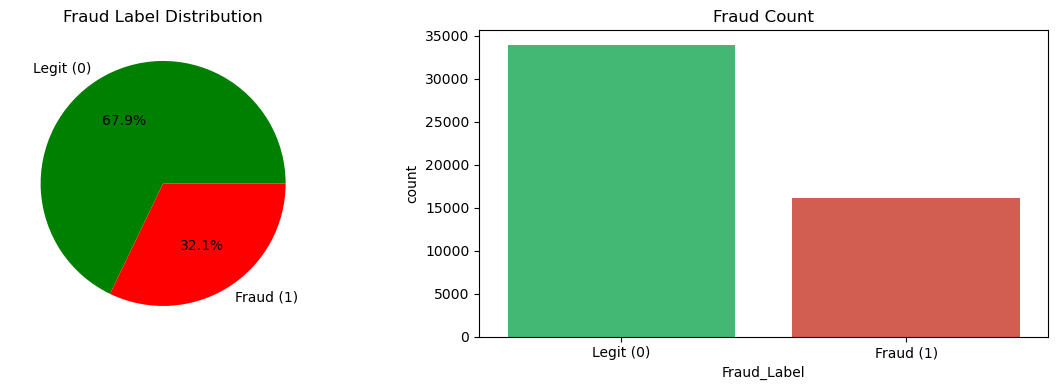

In [8]:
# Q1: Target class distribution
fraud_counts = df['Fraud_Label'].value_counts()
print(fraud_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(fraud_counts, labels=['Legit (0)','Fraud (1)'],
            autopct='%1.1f%%', colors=['green','red'])
axes[0].set_title('Fraud Label Distribution')

sns.countplot(x='Fraud_Label', data=df,
              palette=['#2ecc71','#e74c3c'], ax=axes[1])
axes[1].set_title('Fraud Count')
axes[1].set_xticklabels(['Legit (0)','Fraud (1)'])
plt.tight_layout()
plt.show()

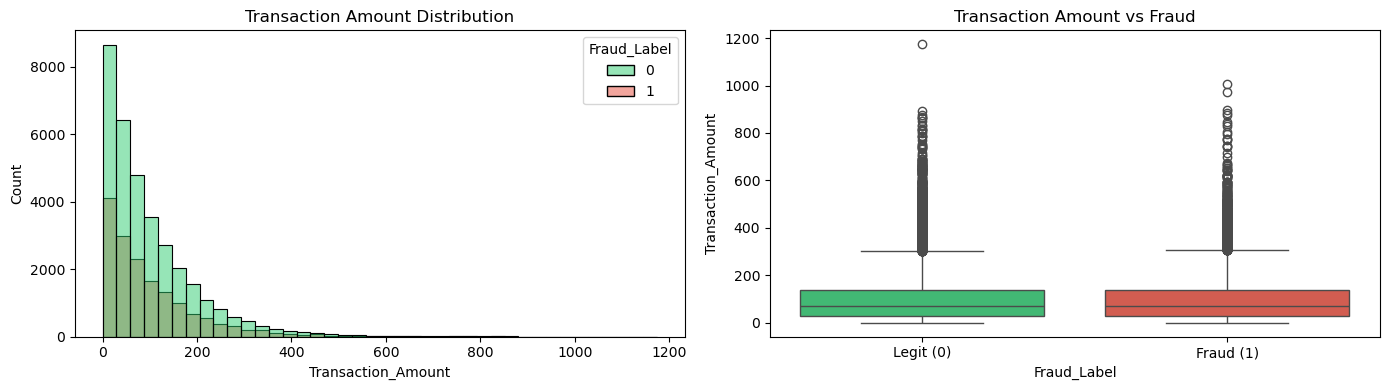

Fraud_Label
0    99.281907
1    99.683678
Name: Transaction_Amount, dtype: float64


In [9]:
# Q2: Transaction Amount distribution by Fraud
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x='Transaction_Amount', hue='Fraud_Label',
             bins=40, palette=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')

sns.boxplot(x='Fraud_Label', y='Transaction_Amount', data=df,
            palette=['#2ecc71','#e74c3c'], ax=axes[1])
axes[1].set_title('Transaction Amount vs Fraud')
axes[1].set_xticklabels(['Legit (0)','Fraud (1)'])
plt.tight_layout()
plt.show()

print(df.groupby('Fraud_Label')['Transaction_Amount'].mean())

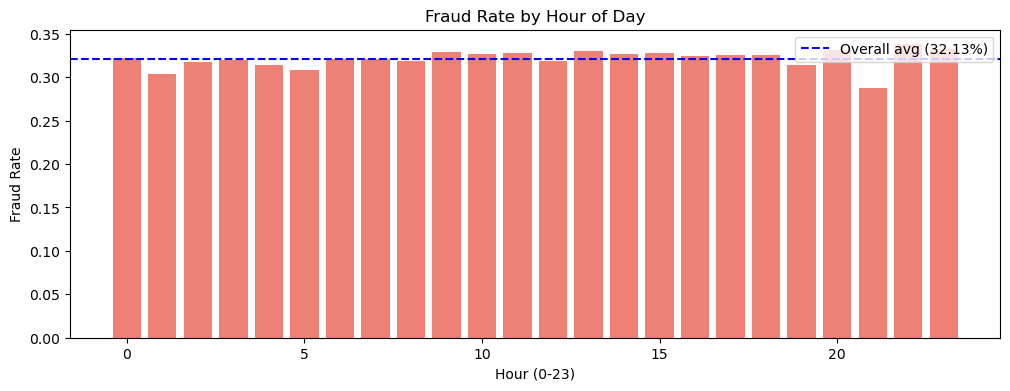

In [10]:
# Q3: Fraud rate by Hour of Day
hour_fraud = df.groupby('Hour')['Fraud_Label'].mean()

plt.figure(figsize=(12, 4))
plt.bar(hour_fraud.index, hour_fraud.values, color='#e74c3c', alpha=0.7)
plt.axhline(y=df['Fraud_Label'].mean(), color='blue',
            linestyle='--', label=f'Overall avg ({df["Fraud_Label"].mean():.2%})')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Fraud Rate')
plt.legend()
plt.show()

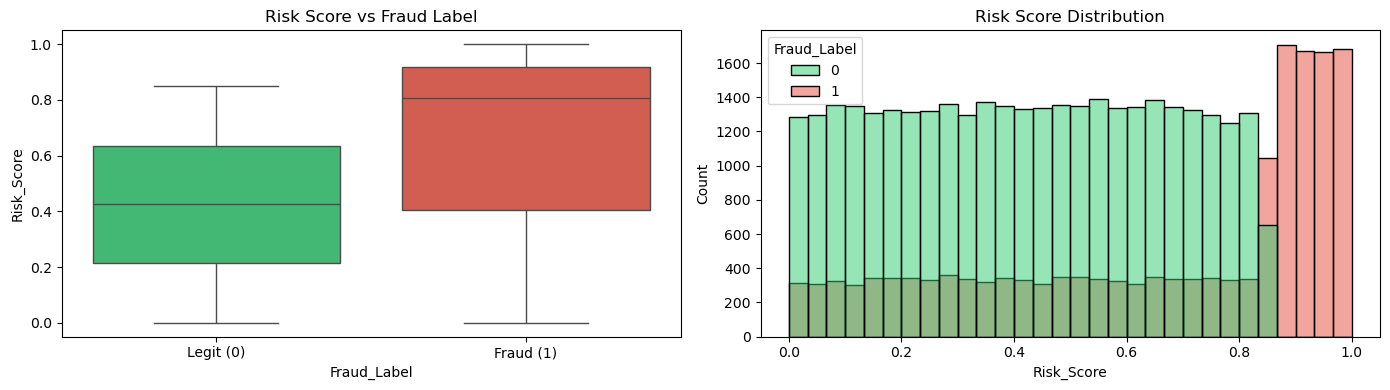

Avg Risk Score by class:
Fraud_Label
0    0.4252
1    0.6629
Name: Risk_Score, dtype: float64


In [11]:
# Q4: Risk Score vs Fraud
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x='Fraud_Label', y='Risk_Score', data=df,
            palette=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Risk Score vs Fraud Label')
axes[0].set_xticklabels(['Legit (0)','Fraud (1)'])

sns.histplot(data=df, x='Risk_Score', hue='Fraud_Label',
             bins=30, palette=['#2ecc71','#e74c3c'], ax=axes[1])
axes[1].set_title('Risk Score Distribution')
plt.tight_layout()
plt.show()

print('Avg Risk Score by class:')
print(df.groupby('Fraud_Label')['Risk_Score'].mean().round(4))

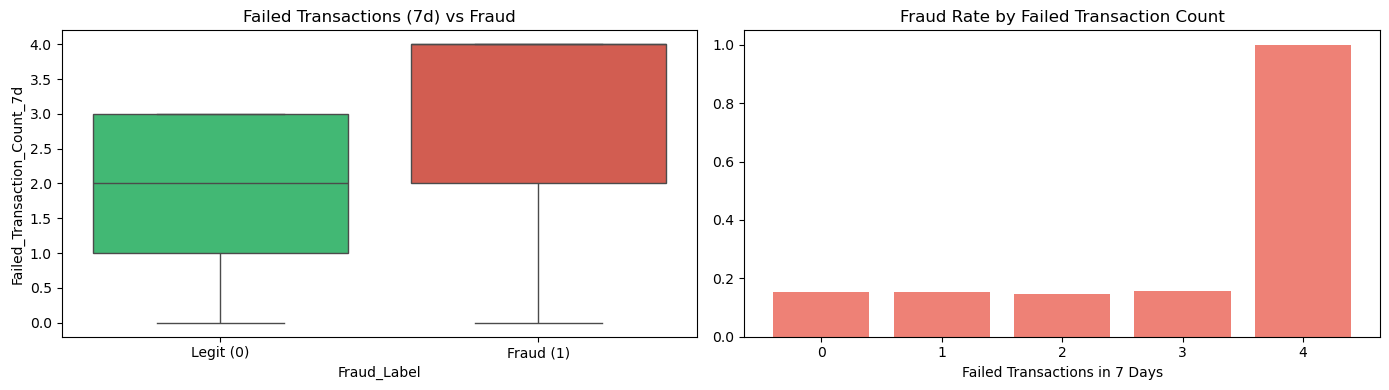

In [12]:
# Q5: Failed Transactions vs Fraud
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x='Fraud_Label', y='Failed_Transaction_Count_7d', data=df,
            palette=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Failed Transactions (7d) vs Fraud')
axes[0].set_xticklabels(['Legit (0)','Fraud (1)'])

failed_fraud = df.groupby('Failed_Transaction_Count_7d')['Fraud_Label'].mean()
axes[1].bar(failed_fraud.index, failed_fraud.values, color='#e74c3c', alpha=0.7)
axes[1].set_title('Fraud Rate by Failed Transaction Count')
axes[1].set_xlabel('Failed Transactions in 7 Days')
plt.tight_layout()
plt.show()

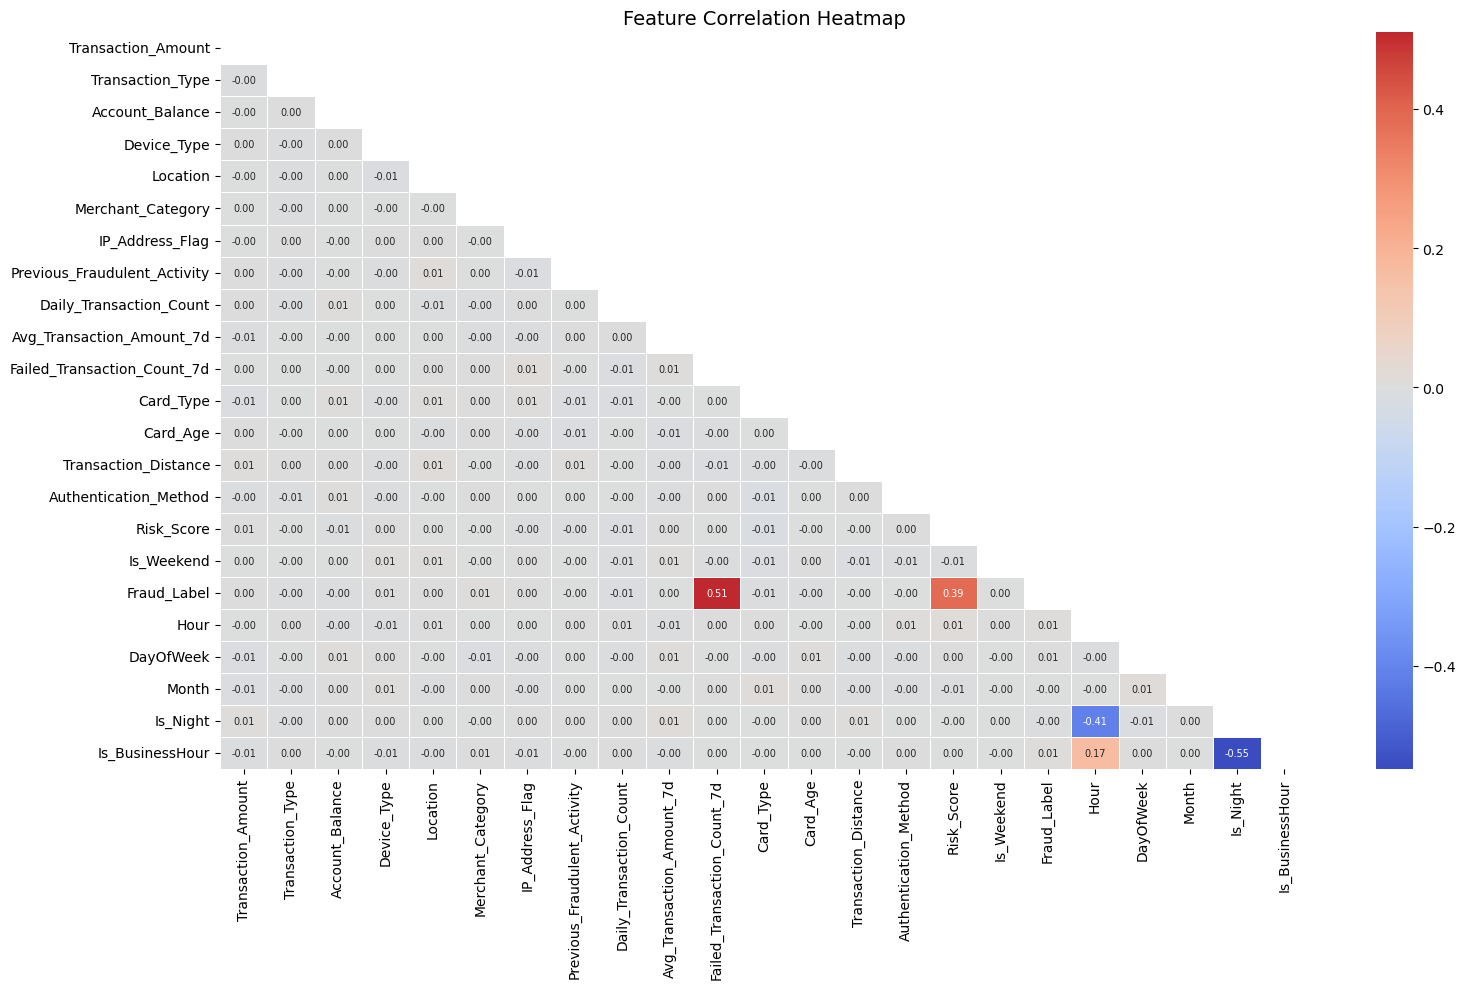

Top correlations with Fraud_Label:
Failed_Transaction_Count_7d    0.509871
Risk_Score                     0.385810
Is_BusinessHour                0.008077
Daily_Transaction_Count       -0.007065
Hour                           0.005822
Merchant_Category              0.005734
Device_Type                    0.005368
Card_Type                     -0.005331
Name: Fraud_Label, dtype: float64


In [13]:
# Q6: Correlation Heatmap
plt.figure(figsize=(16, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with target
print('Top correlations with Fraud_Label:')
print(corr['Fraud_Label'].drop('Fraud_Label').sort_values(key=abs, ascending=False).head(8))

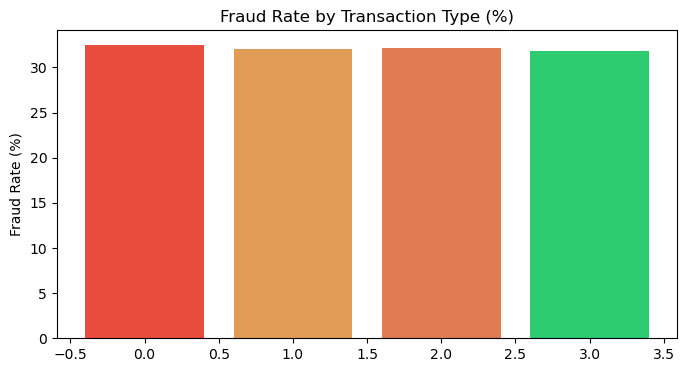

Transaction_Type
0    32.49
2    32.13
1    32.08
3    31.84
Name: Fraud_Label, dtype: float64


In [14]:
# Q7: Fraud rate by Transaction Type
fraud_by_type = df.groupby('Transaction_Type')['Fraud_Label'].mean() * 100
fraud_by_type = fraud_by_type.sort_values(ascending=False)


plt.figure(figsize=(8, 4))
plt.bar(fraud_by_type.index, fraud_by_type.values,
        color=['#e74c3c','#e07b54','#e09c54','#2ecc71'])
plt.title('Fraud Rate by Transaction Type (%)')
plt.ylabel('Fraud Rate (%)')
plt.show()
print(fraud_by_type.round(2))